## Regressions by sector

  Using year: 2023

  SECTOR: Advanced Manufacturing  (N = 296)

  -- model_1 → lq_emp --
  ✓  VIF OK (all < 5)
  [ lq_emp ]  N=279  R²=0.401  R²adj=0.374  AIC=648.5
    Significant (p<0.05): ['apprenticeship_starts', 'n_universities_feecap_lad']

  -- model_2 → lq_bus --
  ✓  VIF OK (all < 5)
  [ lq_bus ]  N=279  R²=0.395  R²adj=0.367  AIC=246.0
    Significant (p<0.05): ['nvq_level3', 'apprenticeship_starts', 'fe_participation', 'enterprise_high_growth_rate']


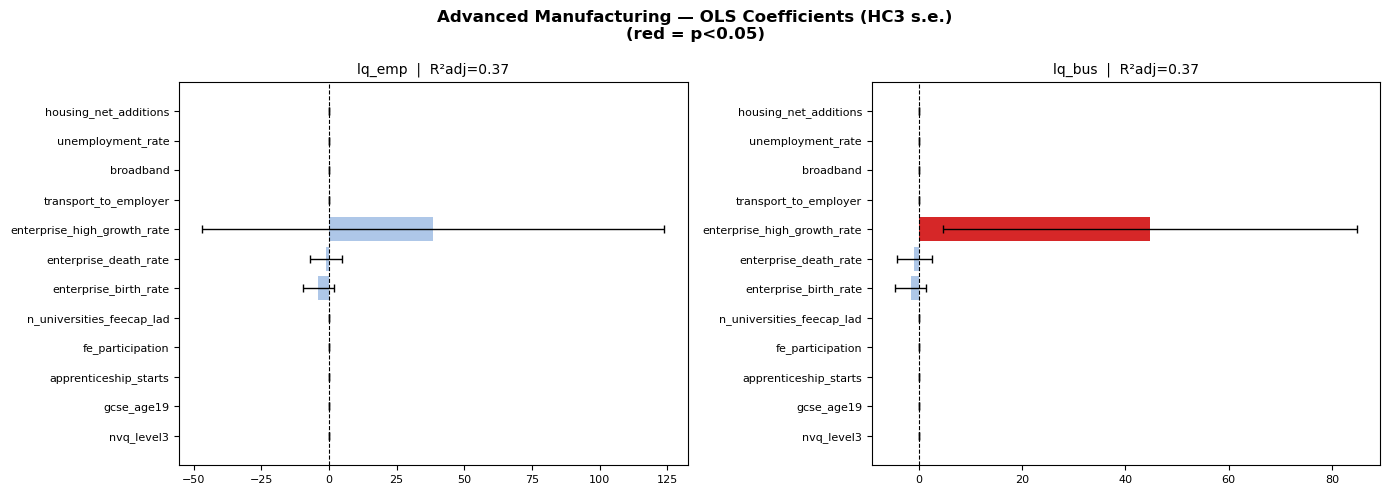


  SECTOR: Clean Energy Industries  (N = 0)

  -- model_1 → lq_emp --
  ⚠️  Not enough observations for VIF (N=0)
  ✓  VIF OK (all < 5)
  ✗  Error in model_1 → lq_emp: zero-size array to reduction operation maximum which has no identity

  -- model_2 → lq_bus --
  ⚠️  Not enough observations for VIF (N=0)
  ✓  VIF OK (all < 5)
  ✗  Error in model_2 → lq_bus: zero-size array to reduction operation maximum which has no identity


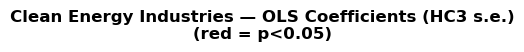


  SECTOR: Creative Industries  (N = 296)

  -- model_1 → lq_emp --
  ✓  VIF OK (all < 5)
  [ lq_emp ]  N=279  R²=0.624  R²adj=0.607  AIC=300.4
    Significant (p<0.05): ['nvq_level3', 'apprenticeship_starts', 'n_universities_feecap_lad', 'transport_to_employer', 'broadband', 'housing_net_additions']

  -- model_2 → lq_bus --
  ✓  VIF OK (all < 5)
  [ lq_bus ]  N=279  R²=0.728  R²adj=0.716  AIC=89.9
    Significant (p<0.05): ['nvq_level3', 'gcse_age19', 'apprenticeship_starts', 'n_universities_feecap_lad', 'enterprise_birth_rate', 'enterprise_death_rate', 'transport_to_employer', 'broadband']


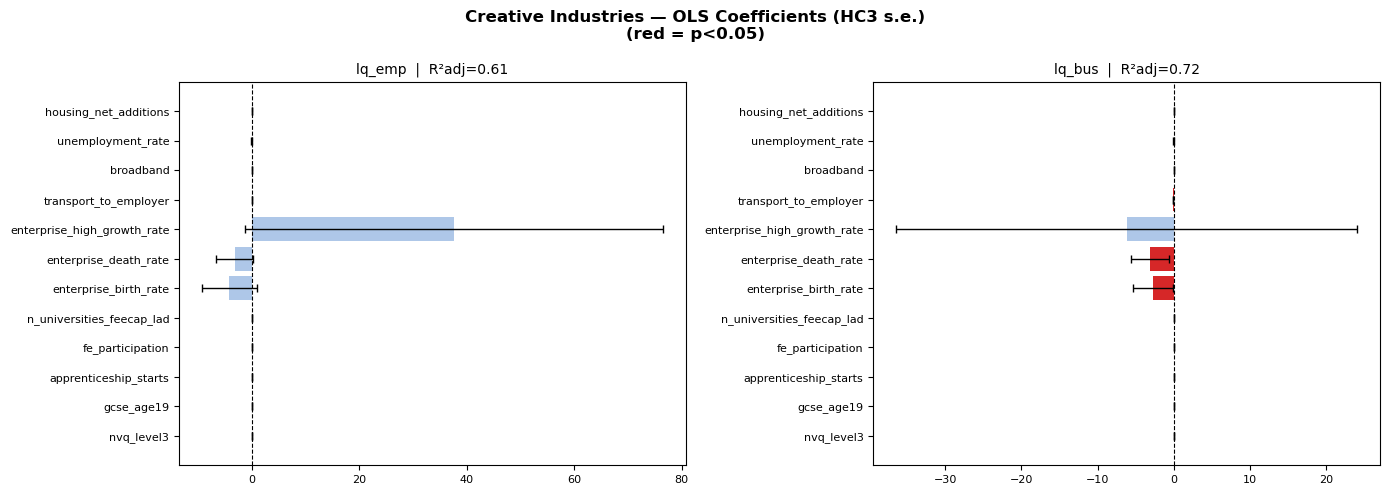


  SECTOR: Digital and Technologies  (N = 296)

  -- model_1 → lq_emp --
  ✓  VIF OK (all < 5)
  [ lq_emp ]  N=279  R²=0.484  R²adj=0.461  AIC=314.3
    Significant (p<0.05): ['nvq_level3', 'fe_participation', 'n_universities_feecap_lad', 'enterprise_birth_rate', 'enterprise_high_growth_rate', 'broadband', 'housing_net_additions']

  -- model_2 → lq_bus --
  ✓  VIF OK (all < 5)
  [ lq_bus ]  N=279  R²=0.664  R²adj=0.649  AIC=-53.2
    Significant (p<0.05): ['nvq_level3', 'gcse_age19', 'apprenticeship_starts', 'enterprise_birth_rate', 'transport_to_employer', 'broadband', 'housing_net_additions']


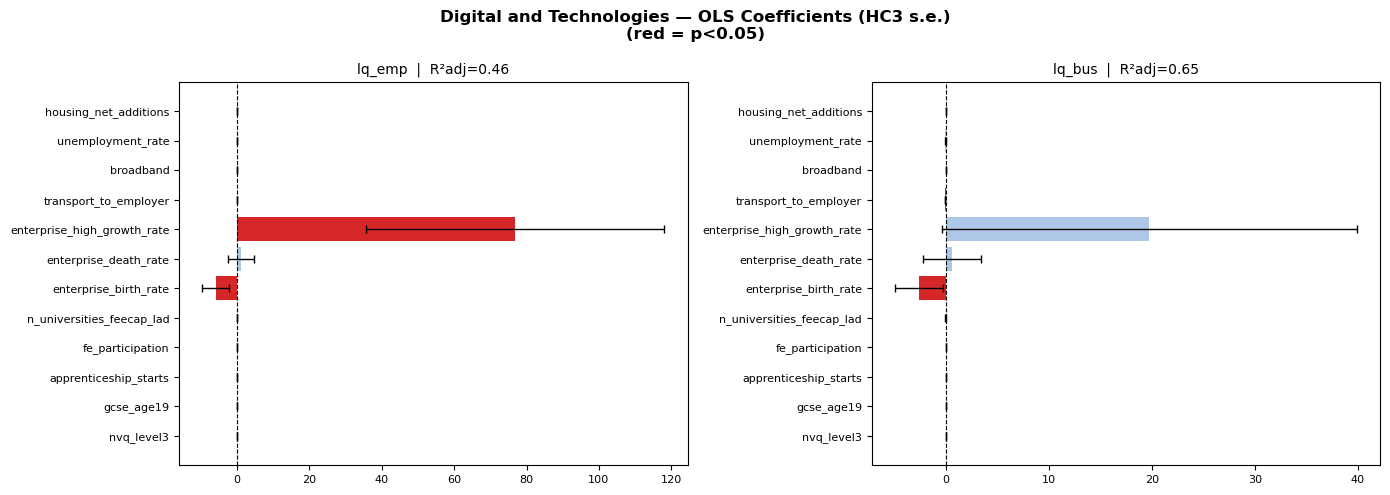


  SECTOR: Financial Services  (N = 296)

  -- model_1 → lq_emp --
  ✓  VIF OK (all < 5)
  [ lq_emp ]  N=279  R²=0.230  R²adj=0.196  AIC=632.4
    Significant (p<0.05): ['fe_participation', 'n_universities_feecap_lad', 'transport_to_employer', 'broadband']

  -- model_2 → lq_bus --
  ✓  VIF OK (all < 5)
  [ lq_bus ]  N=279  R²=0.316  R²adj=0.285  AIC=133.1
    Significant (p<0.05): ['fe_participation', 'n_universities_feecap_lad', 'enterprise_birth_rate', 'enterprise_high_growth_rate', 'transport_to_employer']


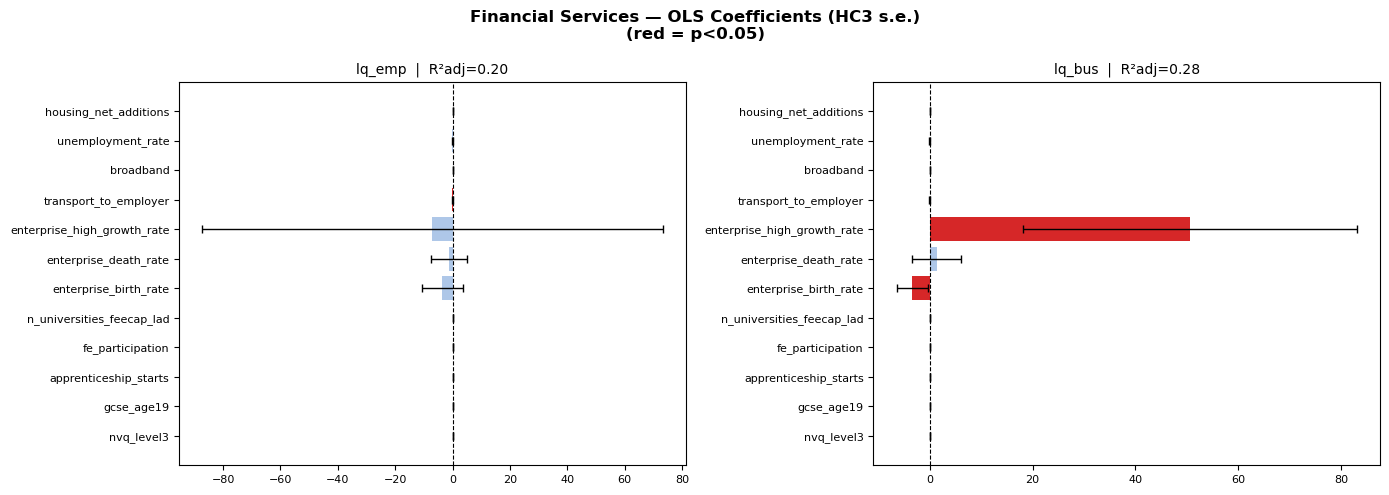


  SECTOR: Life Sciences  (N = 296)

  -- model_1 → lq_emp --
  ✓  VIF OK (all < 5)
  [ lq_emp ]  N=264  R²=0.116  R²adj=0.074  AIC=853.6
    Significant (p<0.05): ['fe_participation', 'enterprise_high_growth_rate']

  -- model_2 → lq_bus --
  ✓  VIF OK (all < 5)
  [ lq_bus ]  N=201  R²=0.250  R²adj=0.202  AIC=349.3
    Significant (p<0.05): ['enterprise_high_growth_rate', 'housing_net_additions']


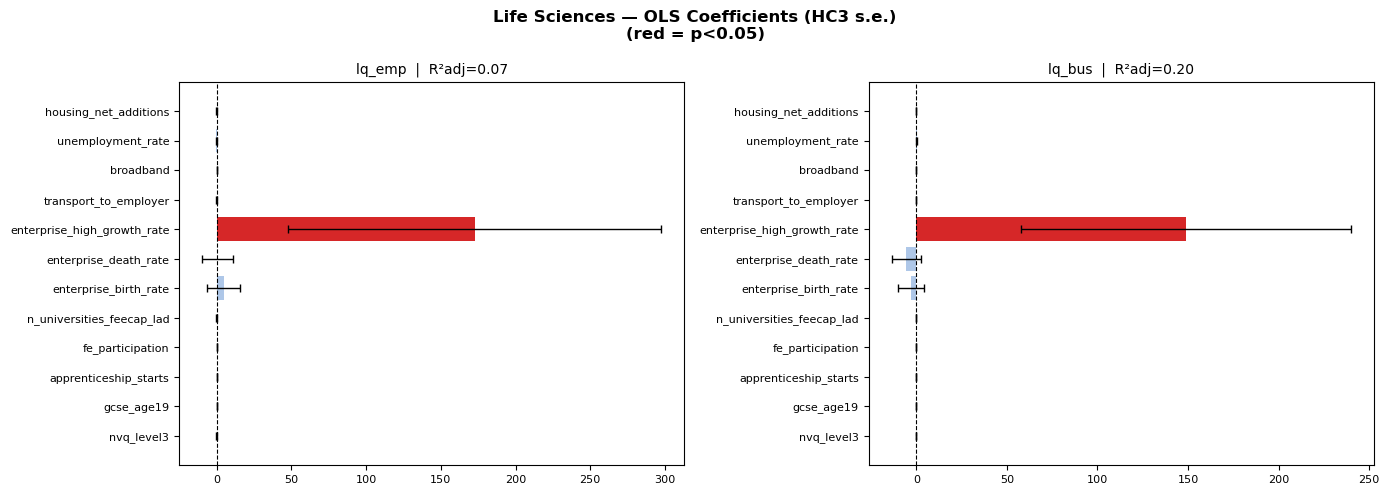


  SECTOR: Professional and Business Services  (N = 296)

  -- model_1 → lq_emp --
  ✓  VIF OK (all < 5)
  [ lq_emp ]  N=279  R²=0.525  R²adj=0.504  AIC=86.6
    Significant (p<0.05): ['gcse_age19', 'fe_participation', 'n_universities_feecap_lad', 'enterprise_high_growth_rate', 'transport_to_employer', 'broadband', 'housing_net_additions']

  -- model_2 → lq_bus --
  ✓  VIF OK (all < 5)
  [ lq_bus ]  N=279  R²=0.748  R²adj=0.736  AIC=-300.4
    Significant (p<0.05): ['nvq_level3', 'gcse_age19', 'apprenticeship_starts', 'n_universities_feecap_lad', 'enterprise_birth_rate', 'transport_to_employer', 'broadband', 'housing_net_additions']


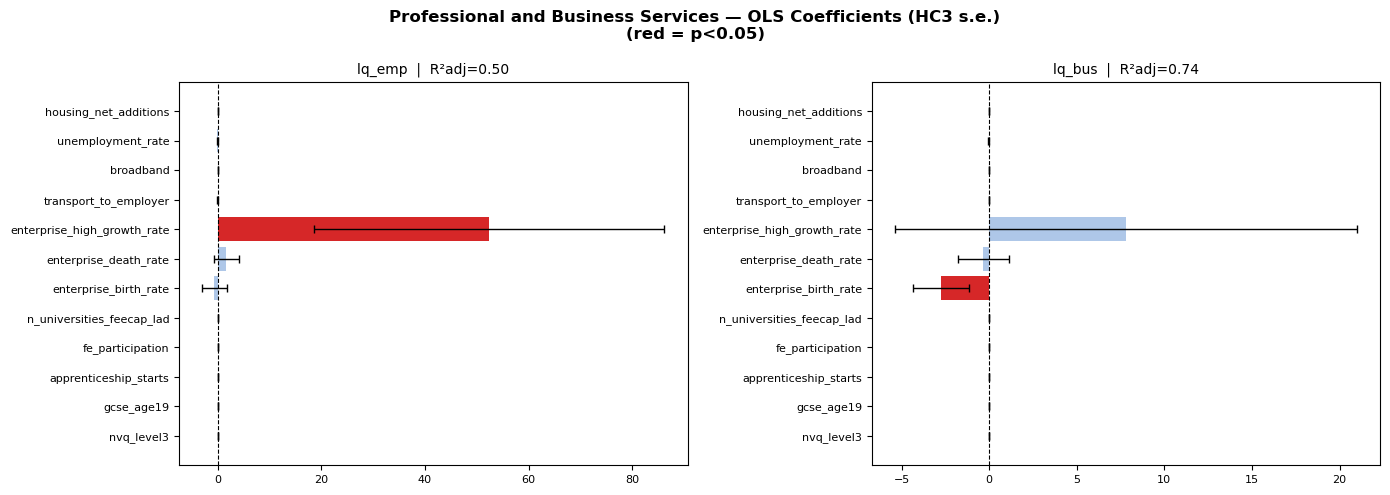


SUMMARY — ADJUSTED R² BY SECTOR AND METRIC
                                    R2adj_lq_emp  R2adj_lq_bus
Sector                                                        
Advanced Manufacturing                     0.374         0.367
Clean Energy Industries                      NaN           NaN
Creative Industries                        0.607         0.716
Digital and Technologies                   0.461         0.649
Financial Services                         0.196         0.285
Life Sciences                              0.074         0.202
Professional and Business Services         0.504         0.736

SOUTH YORKSHIRE RESIDUALS
                            Sector dep_var  mean_residual  n_lads_sy
            Advanced Manufacturing  lq_emp         -0.206          4
            Advanced Manufacturing  lq_bus          0.240          4
               Creative Industries  lq_emp         -0.355          4
               Creative Industries  lq_bus         -0.114          4
          Digital

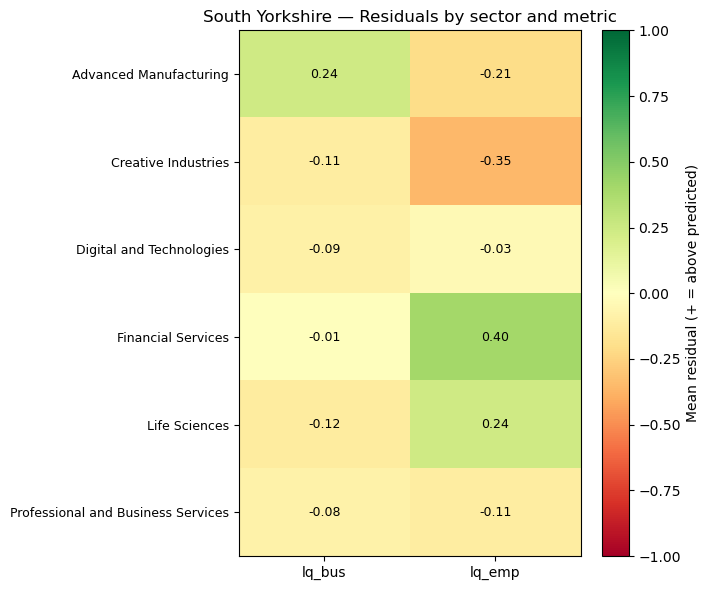

In [9]:
import pandas as pd
import numpy as np
import yaml
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. CONFIGURATION — load variables from config.yml
#    All sectors use the same features_theory for both lq_emp and lq_bus
# =============================================================================

root = next(p for p in Path.cwd().parents if (p / "config.yml").exists())

with open(root / "config.yml", "r") as f:
    config = yaml.safe_load(f)

eeg_groups      = config["parameters"]["eeg_groups"]
features_theory = [var for vars_list in eeg_groups.values() for var in vars_list]

SECTORS = [
    "Advanced Manufacturing",
    "Clean Energy Industries",
    "Creative Industries",
    "Digital and Technologies",
    "Financial Services",
    "Life Sciences",
    "Professional and Business Services",
]

SECTOR_SPECS = {
    sector: {
        "model_1": features_theory,  # → lq_emp
        "model_2": features_theory,  # → lq_bus
    }
    for sector in SECTORS
}

BASE_CONTROLS = []

DEP_VAR_MAP = {
    "lq_emp": "log_lq_emp",
    "lq_bus": "log_lq_bus",
}

SY_LAD_CODES = ["E08000016", "E08000017", "E08000018", "E08000019"]

# =============================================================================
# 2. DATA PREPARATION
# =============================================================================

def prepare_data(df):
    """
    Filters England-only LADs, takes 2023,
    renames problematic columns, splits by sector (one row per LAD).
    """
    df = df.rename(columns={
        "level_3+_qualifications": "level_3plus_qualifications",
        "4g_area_coverage":        "fg_area_coverage",
    })

    df_eng   = df[df["GEOGRAPHY_CODE"].astype(str).str.startswith("E")].copy()
    end_year = 2023
    print(f"  Using year: {end_year}")
    df_year  = df_eng[df_eng["YEAR"] == end_year].copy()

    for lq_col in ["lq_emp", "lq_bus"]:
        df_year[f"log_{lq_col}"] = np.log(df_year[lq_col].replace(0, np.nan))

    sector_dfs = {}
    for sector in SECTOR_SPECS.keys():
        df_s = df_year[df_year["IS8_SECTOR"] == sector].copy()
        df_s = df_s.drop_duplicates(subset="GEOGRAPHY_CODE")
        sector_dfs[sector] = df_s

    return sector_dfs

# =============================================================================
# 3. DIAGNOSTICS
# =============================================================================

def check_vif(df, indep_vars):
    valid_vars = [v for v in indep_vars if v in df.columns]
    missing    = set(indep_vars) - set(valid_vars)
    if missing:
        print(f"  ⚠️  Variables not found (excluded from VIF): {missing}")

    X = df[valid_vars].dropna()
    if X.empty or X.shape[0] < X.shape[1] + 1:
        print(f"  ⚠️  Not enough observations for VIF (N={len(X)})")
        return pd.DataFrame({"Variable": valid_vars, "VIF": [np.nan] * len(valid_vars)})

    X = X.assign(const=1)
    vif = pd.DataFrame({
        "Variable": valid_vars,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(len(valid_vars))]
    }).sort_values("VIF", ascending=False)
    return vif

# =============================================================================
# 4. REGRESSION PER SECTOR
# =============================================================================

def run_sector_regressions(df_sector, sector_name, spec, base_controls, verbose=True):
    """
    Runs 2 OLS models per sector:
      model_1 variables → lq_emp
      model_2 variables → lq_bus
    Uses HC3 robust standard errors.
    """
    dep_model_map = {
        "model_1": ("lq_emp", "log_lq_emp"),
        "model_2": ("lq_bus", "log_lq_bus"),
    }

    results = {}

    if verbose:
        print(f"\n{'='*65}")
        print(f"  SECTOR: {sector_name}  (N = {len(df_sector)})")
        print(f"{'='*65}")

    for model_key, (dep_key, dep_col) in dep_model_map.items():
        indep_vars = spec[model_key]
        all_indep  = indep_vars + [c for c in base_controls if c not in indep_vars]

        if verbose:
            print(f"\n  -- {model_key} → {dep_key} --")
            vif      = check_vif(df_sector, all_indep)
            high_vif = vif[vif["VIF"] > 5]
            if not high_vif.empty:
                print(f"  ⚠️  VIF > 5: {high_vif['Variable'].tolist()}")
            else:
                print("  ✓  VIF OK (all < 5)")

        all_vars = [dep_col] + all_indep
        df_clean = df_sector[[c for c in all_vars + ["GEOGRAPHY_CODE"] if c in df_sector.columns]].dropna()
        n        = len(df_clean)

        all_indep_present = [v for v in all_indep if v in df_clean.columns]
        formula = f"{dep_col} ~ {' + '.join(all_indep_present)}"
        try:
            m = smf.ols(formula, data=df_clean).fit(cov_type='HC3')
            results[dep_key] = {"model": m, "df_clean": df_clean, "n": n}

            if verbose:
                print(f"  [ {dep_key} ]  N={n}  R²={m.rsquared:.3f}  "
                      f"R²adj={m.rsquared_adj:.3f}  AIC={m.aic:.1f}")
                sig_vars = m.pvalues[m.pvalues < 0.05].drop("Intercept", errors="ignore")
                if not sig_vars.empty:
                    print(f"    Significant (p<0.05): {sig_vars.index.tolist()}")

        except Exception as e:
            print(f"  ✗  Error in {model_key} → {dep_key}: {e}")
            results[dep_key] = None

    return results

# =============================================================================
# 5. VISUALISATION
# =============================================================================

def plot_coef_grid(sector_results, sector_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, dep_key in zip(axes, ["lq_emp", "lq_bus"]):
        res = sector_results.get(dep_key)
        if res is None:
            ax.set_visible(False)
            continue

        m      = res["model"]
        coef   = m.params.drop("Intercept", errors="ignore")
        ci     = m.conf_int().drop("Intercept", errors="ignore")
        sig    = m.pvalues.drop("Intercept", errors="ignore") < 0.05
        colors = ["#d62728" if s else "#aec7e8" for s in sig]

        ax.barh(coef.index, coef.values, color=colors,
                xerr=[coef - ci[0], ci[1] - coef],
                capsize=3, error_kw={"elinewidth": 1})
        ax.axvline(0, color="black", lw=0.8, ls="--")
        ax.set_title(f"{dep_key}  |  R²adj={m.rsquared_adj:.2f}", fontsize=10)
        ax.tick_params(labelsize=8)

    fig.suptitle(f"{sector_name} — OLS Coefficients (HC3 s.e.)\n(red = p<0.05)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"coef_{sector_name.replace(' ', '_')}.png", dpi=150)
    plt.show()


def plot_sy_residuals(sy_summary):
    pivot = sy_summary.pivot(index="Sector", columns="dep_var", values="mean_residual")
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=-1, vmax=1)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=10)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)
    plt.colorbar(im, ax=ax, label="Mean residual (+ = above predicted)")
    ax.set_title("South Yorkshire — Residuals by sector and metric", fontsize=12)
    plt.tight_layout()
    plt.savefig("sy_residuals_heatmap.png", dpi=150)
    plt.show()

# =============================================================================
# 6. MAIN
# =============================================================================

def main(df):
    sector_dfs  = prepare_data(df)
    all_results = {}
    sy_rows     = []

    for sector, spec in SECTOR_SPECS.items():
        df_s    = sector_dfs[sector]
        results = run_sector_regressions(df_s, sector, spec, BASE_CONTROLS)
        all_results[sector] = results

        plot_coef_grid(results, sector)

        for dep_key, res in results.items():
            if res is None:
                continue
            m        = res["model"]
            df_c     = res["df_clean"]
            sy_mask  = df_c["GEOGRAPHY_CODE"].isin(SY_LAD_CODES)
            sy_resid = m.resid[sy_mask]
            sy_rows.append({
                "Sector":        sector,
                "dep_var":       dep_key,
                "mean_residual": round(sy_resid.mean(), 3),
                "n_lads_sy":     sy_mask.sum(),
            })

    summary_rows = []
    for sector, results in all_results.items():
        row = {"Sector": sector}
        for dep_key, res in results.items():
            if res:
                row[f"R2adj_{dep_key}"] = round(res["model"].rsquared_adj, 3)
        summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows).set_index("Sector")
    print("\n" + "="*65)
    print("SUMMARY — ADJUSTED R² BY SECTOR AND METRIC")
    print("="*65)
    print(summary_df.to_string())

    sy_summary = pd.DataFrame(sy_rows)
    print("\n" + "="*65)
    print("SOUTH YORKSHIRE RESIDUALS")
    print("="*65)
    print(sy_summary.to_string(index=False))

    plot_sy_residuals(sy_summary)

    return all_results, summary_df, sy_summary


# =============================================================================
# RUN
# =============================================================================
df = pd.read_parquet(root / "data/processed_data/analysis_panel.parquet", engine="fastparquet")

all_results, summary_df, sy_summary = main(df)

# To inspect a full model summary:
# print(all_results["Advanced Manufacturing"]["lq_emp"]["model"].summary())

## Regressions - Pooled OLS

  Using year: 2023
All unique variables pooled (12):
['apprenticeship_starts', 'broadband', 'enterprise_birth_rate', 'enterprise_death_rate', 'enterprise_high_growth_rate', 'fe_participation', 'gcse_age19', 'housing_net_additions', 'n_universities_feecap_lad', 'nvq_level3', 'transport_to_employer', 'unemployment_rate']

  POOLED — lq_emp  (N=1659)
  R²=0.173  R²adj=0.165  AIC=3892.7
  Significant vars    (p<0.05): ['broadband', 'enterprise_high_growth_rate', 'fe_participation', 'housing_net_additions', 'n_universities_feecap_lad']
  Significant dummies (p<0.05): ['C(IS8_SECTOR)[T.Creative Industries]', 'C(IS8_SECTOR)[T.Financial Services]', 'C(IS8_SECTOR)[T.Life Sciences]']

  POOLED — lq_bus  (N=1596)
  R²=0.208  R²adj=0.200  AIC=1599.5
  Significant vars    (p<0.05): ['broadband', 'enterprise_birth_rate', 'enterprise_high_growth_rate', 'fe_participation', 'housing_net_additions', 'nvq_level3', 'transport_to_employer']
  Significant dummies (p<0.05): ['C(IS8_SECTOR)[T.Creative Industr

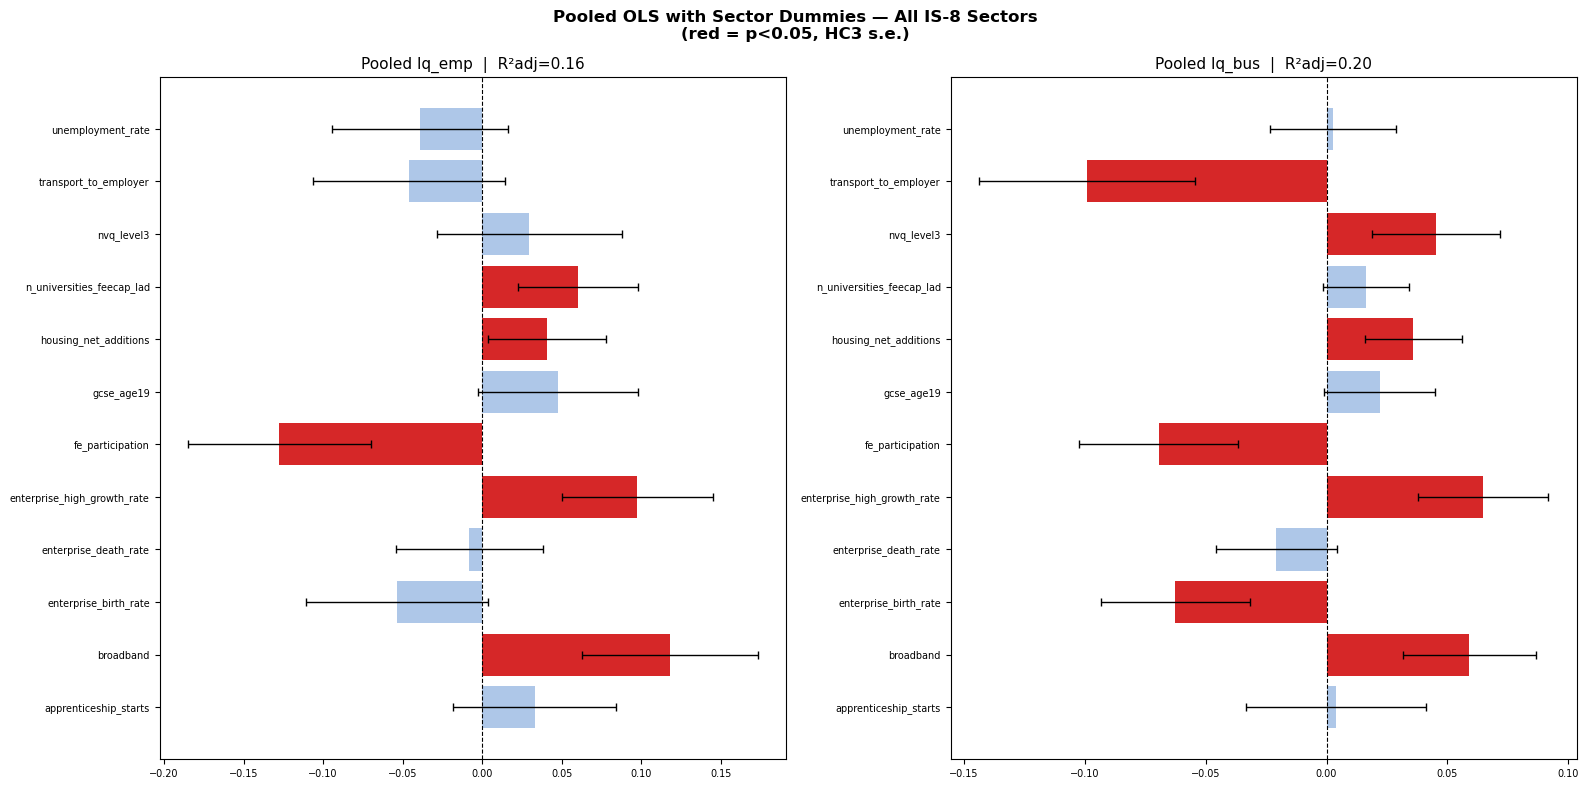

                            OLS Regression Results                            
Dep. Variable:             log_lq_emp   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     31.36
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.06e-54
Time:                        21:48:50   Log-Likelihood:                -1928.3
No. Observations:                1659   AIC:                             3893.
Df Residuals:                    1641   BIC:                             3990.
Df Model:                          17                                         
Covariance Type:              cluster                                         
                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [7]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# =============================================================================
# POOLED OLS WITH SECTOR DUMMIES
# One regression per dep_var (lq_emp, lq_bus) using all observations,
# with all unique variables from SECTOR_SPECS + sector dummies.
# =============================================================================

def run_pooled_regressions(df, sector_dfs, sector_specs, all_vars, verbose=True):
    """
    Builds a pooled dataset (all sectors stacked) and runs two OLS models:
      - Model A: log_lq_emp ~ all_vars + sector_dummies
      - Model B: log_lq_bus ~ all_vars + sector_dummies
    """

    # All vars passed in directly from features_theory
    all_vars = sorted([v for v in all_vars if v in next(iter(sector_dfs.values())).columns])

    if verbose:
        print(f"All unique variables pooled ({len(all_vars)}):")
        print(all_vars)

    # --- Stack sector DataFrames ---
    frames = []
    for sector, df_s in sector_dfs.items():
        tmp = df_s.copy()
        tmp["IS8_SECTOR"] = sector
        frames.append(tmp)
    df_pool = pd.concat(frames, ignore_index=True)

    # Ensure log LQ columns exist
    for lq_col in ["lq_emp", "lq_bus"]:
        if f"log_{lq_col}" not in df_pool.columns:
            df_pool[f"log_{lq_col}"] = np.log(df_pool[lq_col].replace(0, np.nan))

    # Standardise all independent variables (mean=0, std=1)
    # so coefficients are comparable across variables
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    vars_present = [v for v in all_vars if v in df_pool.columns]
    df_pool[vars_present] = scaler.fit_transform(df_pool[vars_present])

    # --- Build formula ---
    # Sector dummies via C(IS8_SECTOR) — statsmodels drops one category as baseline
    sector_term = "C(IS8_SECTOR)"
    rhs = " + ".join(all_vars) + " + " + sector_term

    results = {}

    for dep_key, dep_col in {"lq_emp": "log_lq_emp", "lq_bus": "log_lq_bus"}.items():
        cols_needed = [dep_col, "IS8_SECTOR", "GEOGRAPHY_CODE"] + all_vars
        df_clean = df_pool[[c for c in cols_needed if c in df_pool.columns]].dropna()
        n = len(df_clean)

        formula = f"{dep_col} ~ {rhs}"
        try:
            m = smf.ols(formula, data=df_clean).fit(
                cov_type="cluster",
                cov_kwds={"groups": df_clean["GEOGRAPHY_CODE"]}
            )
            results[dep_key] = {"model": m, "df_clean": df_clean, "n": n}

            if verbose:
                print(f"\n{'='*65}")
                print(f"  POOLED — {dep_key}  (N={n})")
                print(f"{'='*65}")
                print(f"  R²={m.rsquared:.3f}  R²adj={m.rsquared_adj:.3f}  AIC={m.aic:.1f}")
                sig = m.pvalues[m.pvalues < 0.05].drop("Intercept", errors="ignore")
                # Separate sector dummies from substantive vars
                sig_vars    = [v for v in sig.index if "IS8_SECTOR" not in v]
                sig_dummies = [v for v in sig.index if "IS8_SECTOR" in v]
                print(f"  Significant vars    (p<0.05): {sig_vars}")
                print(f"  Significant dummies (p<0.05): {sig_dummies}")

        except Exception as e:
            print(f"  ✗  Error in pooled {dep_key}: {e}")
            results[dep_key] = None

    return results


def plot_pooled_coefs(pooled_results):
    """
    Side-by-side coefficient plots for pooled lq_emp and lq_bus.
    Sector dummies plotted separately at the bottom.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    for ax, dep_key in zip(axes, ["lq_emp", "lq_bus"]):
        res = pooled_results.get(dep_key)
        if res is None:
            ax.set_visible(False)
            continue

        m    = res["model"]
        coef = m.params.drop("Intercept", errors="ignore")
        ci   = m.conf_int().drop("Intercept", errors="ignore")
        sig  = m.pvalues.drop("Intercept", errors="ignore") < 0.05

        # Keep only substantive vars (drop sector dummies)
        is_dummy = coef.index.str.contains("IS8_SECTOR")
        coef = coef[~is_dummy]
        ci   = ci[~is_dummy]
        sig  = sig[~is_dummy]

        colors  = ["#d62728" if s else "#aec7e8" for s in sig]
        xerr_lo = coef - ci[0]
        xerr_hi = ci[1] - coef

        ax.barh(coef.index, coef.values, color=colors,
                xerr=[xerr_lo, xerr_hi], capsize=3, error_kw={"elinewidth": 1})
        ax.axvline(0, color="black", lw=0.8, ls="--")
        ax.set_title(f"Pooled {dep_key}  |  R²adj={m.rsquared_adj:.2f}", fontsize=11)
        ax.tick_params(labelsize=7)

    fig.suptitle("Pooled OLS with Sector Dummies — All IS-8 Sectors\n(red = p<0.05, HC3 s.e.)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("pooled_coef_plot.png", dpi=150)
    plt.show()


# =============================================================================
# RUN — uses sector_dfs and SECTOR_SPECS from the main notebook
# =============================================================================

sector_dfs_pooled = prepare_data(df)

# Load features_theory from config if not already in memory
try:
    features_theory
except NameError:
    import yaml
    config_path = next(p for p in Path.cwd().parents if (p / "config.yml").exists()) / "config.yml"
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    eeg_groups      = config["parameters"]["eeg_groups"]
    features_theory = [var for vars_list in eeg_groups.values() for var in vars_list]

pooled_results = run_pooled_regressions(df, sector_dfs_pooled, SECTOR_SPECS, features_theory)
plot_pooled_coefs(pooled_results)

# Full summary
print(pooled_results["lq_emp"]["model"].summary())
print(pooled_results["lq_bus"]["model"].summary())

In [ ]:
from sklearn.preprocessing import StandardScaler

all_vars = set()
for sector, spec in SECTOR_SPECS.items():
    if sector == "Defence":
        continue
    for vars_list in spec.values():
        all_vars.update(vars_list)
all_vars = sorted(all_vars)
print("Variables:", all_vars)

# Check which ones are missing from the pooled df
sector_dfs_pooled = prepare_data(df)
frames = []
for sector, df_s in sector_dfs_pooled.items():
    tmp = df_s.copy()
    tmp["IS8_SECTOR"] = sector
    frames.append(tmp)
df_pool = pd.concat(frames, ignore_index=True)

missing = [v for v in all_vars if v not in df_pool.columns]
print("Missing columns:", missing)

AttributeError: 'list' object has no attribute 'values'

In [ ]:
print(type(list(SECTOR_SPECS.values())[0]))

<class 'list'>


In [ ]:
print(pooled_results)

{'lq_emp': None, 'lq_bus': None}


In [ ]:
df

,YEAR,GEOGRAPHY_CODE,GEOGRAPHY_NAME,IS8_SECTOR,EMPLOYEES,BUSINESSES,unemployment_rate,transport_to_employer,drive_to_employer,cycle_to_employer,...,emp_share,lq_emp,gd_emp,gd_bus,n_years_emp,n_years_bus,related_variety,within_sector_diversity,size_large_share,size_micro_share
0,2016,E06000001,Hartlepool,Advanced Manufacturing,1470.0,25.0,4.6,12.900208,7.790802,10.070582,...,0.048197,1.648198,0.001431,-0.112731,8,8,1.032564,1.332179,0.000000,1.000000
1,2016,E06000001,Hartlepool,Creative Industries,450.0,110.0,4.6,12.900208,7.790802,10.070582,...,0.014754,0.281144,0.044382,-0.014263,8,8,1.032564,2.200516,0.000000,1.000000
2,2016,E06000001,Hartlepool,Defence,0.0,0.0,4.6,12.900208,7.790802,10.070582,...,0.000000,0.000000,NaN,NaN,0,0,1.032564,0.000000,NaN,NaN
3,2016,E06000001,Hartlepool,Digital and Technologies,1510.0,440.0,4.6,12.900208,7.790802,10.070582,...,0.049508,0.682440,-0.026657,-0.059004,8,8,1.032564,1.072313,0.000000,1.000000
4,2016,E06000001,Hartlepool,Financial Services,285.0,40.0,4.6,12.900208,7.790802,10.070582,...,0.009344,0.154102,-0.037470,0.047092,8,8,1.032564,1.213008,0.000000,0.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16571,2023,E09000033,Westminster,Defence,0.0,0.0,4.6,5.082667,6.462280,6.735705,...,0.000000,0.000000,NaN,NaN,0,0,1.280585,0.000000,NaN,NaN
16572,2023,E09000033,Westminster,Digital and Technologies,105660.0,7100.0,4.6,5.082667,6.462280,6.735705,...,0.132439,1.767121,0.012819,0.031918,8,8,1.280585,1.690905,0.009155,0.824648
16573,2023,E09000033,Westminster,Financial Services,97630.0,7655.0,4.6,5.082667,6.462280,6.735705,...,0.122374,2.152160,0.019215,0.014491,8,8,1.280585,1.860277,0.004572,0.816460
16574,2023,E09000033,Westminster,Life Sciences,990.0,115.0,4.6,5.082667,6.462280,6.735705,...,0.001241,0.344372,0.041071,0.017707,8,8,1.280585,1.169992,0.000000,0.782609


## Regression per LAD- lq

Datos: 296 LADs · 6 sectores IS8 · 1776 filas
LQ agregado (sum) para 296 LADs.

  log LQ EMPLEO  |  N=294  R²=0.088  Adj-R²=0.059
                            OLS Regression Results                            
Dep. Variable:             log_lq_emp   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     3.402
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           0.000548
Time:                        03:26:04   Log-Likelihood:                -30.608
No. Observations:                 294   AIC:                             81.22
Df Residuals:                     284   BIC:                             118.1
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.

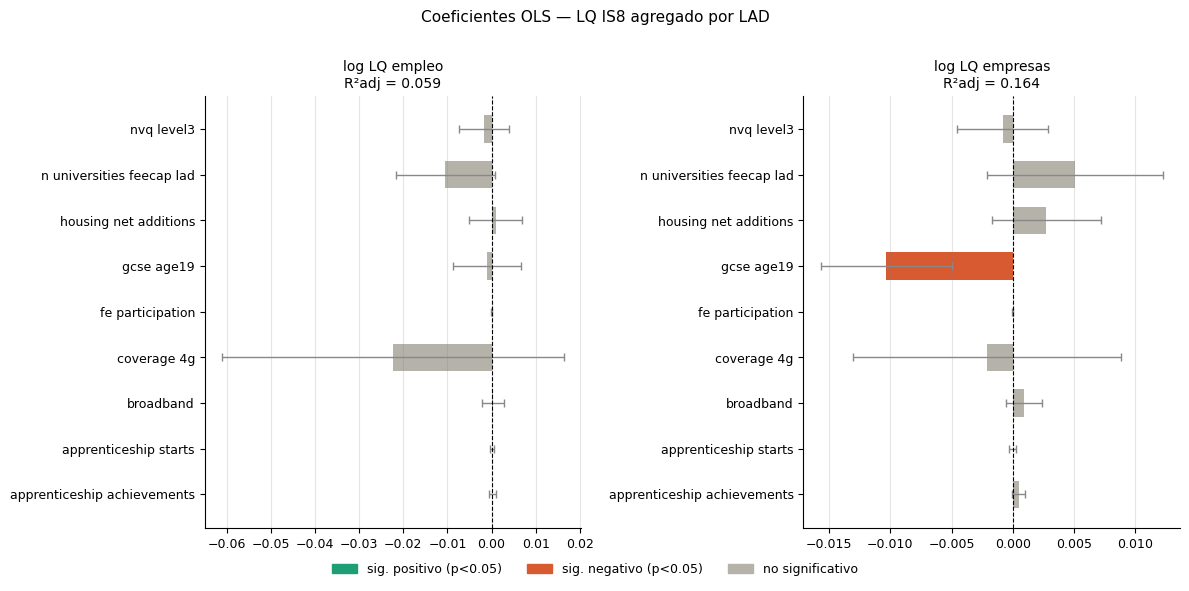

In [15]:
"""
Regresión LAD – LQ IS8 agregado (una obs por LAD)
Trabaja directamente sobre un DataFrame ya cargado en memoria.
Cambia SOLO el bloque CONFIG.
"""

import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────
# CONFIG  ← cambia aquí
# ─────────────────────────────────────────────────────────────────

# Nombre de tu DataFrame ya cargado
INPUT_DF = df                        # ← cambia si se llama distinto (panel, data, etc.)

# Año a filtrar (None = todos los años)
YEAR = 2023

# Columnas de identificación
COL_GEO_CODE = "GEOGRAPHY_CODE"
COL_GEO_NAME = "GEOGRAPHY_NAME"
COL_YEAR     = "YEAR"
COL_SECTOR   = "IS8_SECTOR"

# Columnas de cantidad para recalcular LQ
COL_EMP = "EMPLOYEES"
COL_BUS = "BUSINESSES"

# Sectores IS8 a excluir de la agregación (ej. Defence por ser todo ceros)
EXCLUDE_SECTORS = ["Defence"]

# Cómo agregar el LQ de los sectores en un score único por LAD
# "sum" | "mean" | "max"
LQ_AGGREGATION = "sum"

# Covariables — deben existir como columnas en tu DataFrame
COVARIATES = [
    "apprenticeship_achievements",
    "apprenticeship_starts",
    "broadband",
    "coverage_4g",
    #"enterprise_birth_rate",
    #"enterprise_death_rate",
    "fe_participation",
    "gcse_age19",
    "housing_net_additions",
    "n_universities_feecap_lad",
    "nvq_level3",
]

# Errores estándar robustos: "HC3" | "HC1" | None (OLS clásico)
SE_TYPE = "HC3"

# ─────────────────────────────────────────────────────────────────
# PASO 1 – Filtrar
# ─────────────────────────────────────────────────────────────────

raw = INPUT_DF.copy()

if YEAR is not None:
    raw = raw[raw[COL_YEAR] == YEAR]

if EXCLUDE_SECTORS:
    raw = raw[~raw[COL_SECTOR].isin(EXCLUDE_SECTORS)]

print(f"Datos: {raw[COL_GEO_CODE].nunique()} LADs · "
      f"{raw[COL_SECTOR].nunique()} sectores IS8 · {len(raw)} filas")

# ─────────────────────────────────────────────────────────────────
# PASO 2 – Recalcular LQ y agregar por LAD
# ─────────────────────────────────────────────────────────────────

def aggregate_lq(data, col, agg):
    """Calcula LQ por LAD×sector y lo agrega a nivel LAD."""
    nat_total  = data[col].sum()
    nat_sector = data.groupby(COL_SECTOR)[col].transform("sum")
    lad_total  = data.groupby(COL_GEO_CODE)[col].transform("sum")

    lq = (data[col] / lad_total) / (nat_sector / nat_total)
    lq = lq.where(lad_total > 0)          # NaN si LAD sin actividad

    temp = data[[COL_GEO_CODE, COL_GEO_NAME]].copy()
    temp["lq"] = lq

    return (temp.groupby([COL_GEO_CODE, COL_GEO_NAME])["lq"]
                .agg(agg)
                .reset_index()
                .rename(columns={"lq": f"lq_{col.lower()}"}))

lad_emp = aggregate_lq(raw, COL_EMP, LQ_AGGREGATION)
lad_bus = aggregate_lq(raw, COL_BUS, LQ_AGGREGATION)
lad     = lad_emp.merge(lad_bus, on=[COL_GEO_CODE, COL_GEO_NAME])

# Log-LQ
lad["log_lq_emp"] = np.log(lad[f"lq_{COL_EMP.lower()}"].replace(0, np.nan))
lad["log_lq_bus"] = np.log(lad[f"lq_{COL_BUS.lower()}"].replace(0, np.nan))

print(f"LQ agregado ({LQ_AGGREGATION}) para {len(lad)} LADs.")

# ─────────────────────────────────────────────────────────────────
# PASO 3 – Unir covariables (primera obs por LAD)
# ─────────────────────────────────────────────────────────────────

available = [c for c in COVARIATES if c in raw.columns]
missing   = [c for c in COVARIATES if c not in raw.columns]
if missing:
    print(f"AVISO – covariables no encontradas: {missing}")

lad_covs = (raw[[COL_GEO_CODE] + available]
              .drop_duplicates(COL_GEO_CODE))

panel = lad.merge(lad_covs, on=COL_GEO_CODE, how="left")

# ─────────────────────────────────────────────────────────────────
# PASO 4 – OLS
# ─────────────────────────────────────────────────────────────────

def run_ols(data, dep_var, covs, se, label):
    sub = data[[dep_var] + covs].dropna()
    X   = sm.add_constant(sub[covs].astype(float))
    y   = sub[dep_var].astype(float)
    fit = sm.OLS(y, X).fit(cov_type=se) if se else sm.OLS(y, X).fit()

    print(f"\n{'='*70}")
    print(f"  {label}  |  N={len(sub)}  R²={fit.rsquared:.3f}  Adj-R²={fit.rsquared_adj:.3f}")
    print(f"{'='*70}")
    print(fit.summary())
    return fit, sub.index

model_emp, idx_emp = run_ols(panel, "log_lq_emp", available, SE_TYPE, "log LQ EMPLEO")
model_bus, idx_bus = run_ols(panel, "log_lq_bus", available, SE_TYPE, "log LQ EMPRESAS")

# ─────────────────────────────────────────────────────────────────
# PASO 5 – Tabla comparativa
# ─────────────────────────────────────────────────────────────────

def coef_df(model, suffix):
    t = model.summary2().tables[1].copy()
    # Renombrar columna de p-valor según el tipo de SE (t o z)
    t.columns = [c.strip() for c in t.columns]
    p_col = next((c for c in t.columns if c.startswith("P>")), None)
    t = t[["Coef.", p_col, "[0.025", "0.975]"]]
    t.columns = [f"{c}_{suffix}" for c in ["Coef.", "P>|z|", "[0.025", "0.975]"]]
    return t

comp = coef_df(model_emp, "emp").join(coef_df(model_bus, "bus"))
print("\n── Tabla comparativa emp vs bus ──")
print(comp[["Coef._emp", "P>|z|_emp", "Coef._bus", "P>|z|_bus"]].round(4).to_string())

# ─────────────────────────────────────────────────────────────────
# PASO 6 – DataFrame final con fitted values y residuos
# ─────────────────────────────────────────────────────────────────

panel.loc[idx_emp, "yhat_emp"]  = model_emp.fittedvalues.values
panel.loc[idx_emp, "resid_emp"] = model_emp.resid.values
panel.loc[idx_bus, "yhat_bus"]  = model_bus.fittedvalues.values
panel.loc[idx_bus, "resid_bus"] = model_bus.resid.values

results = panel
print(f"\nDataFrame 'results' listo: {results.shape[0]} LADs × {results.shape[1]} columnas")

# ─────────────────────────────────────────────────────────────────
# PASO 7 – Gráfico de coeficientes (matplotlib)
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

def plot_coefs(model, title, ax):
    params = model.params.drop("const", errors="ignore")
    ci     = model.conf_int().drop("const", errors="ignore")
    pvals  = model.pvalues.drop("const", errors="ignore")

    err_lo = params - ci[0]
    err_hi = ci[1] - params
    colors = ["#1D9E75" if (p < 0.05 and c >= 0) else
              "#D85A30" if (p < 0.05 and c < 0) else
              "#B4B2A9"
              for c, p in zip(params, pvals)]

    y_pos = range(len(params))
    ax.barh(y_pos, params, xerr=[err_lo, err_hi],
            color=colors, capsize=3, height=0.6,
            error_kw={"elinewidth": 1, "ecolor": "#888"})
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([v.replace("_", " ") for v in params.index], fontsize=9)
    ax.set_title(f"{title}\nR²adj = {model.rsquared_adj:.3f}", fontsize=10)
    ax.tick_params(axis="x", labelsize=9)
    ax.grid(axis="x", color="gray", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(12, max(len(available) * 0.5 + 1, 5)))
plot_coefs(model_emp, "log LQ empleo", axes[0])
plot_coefs(model_bus, "log LQ empresas", axes[1])

from matplotlib.patches import Patch
legend_els = [
    Patch(color="#1D9E75", label="sig. positivo (p<0.05)"),
    Patch(color="#D85A30", label="sig. negativo (p<0.05)"),
    Patch(color="#B4B2A9", label="no significativo"),
]
fig.legend(handles=legend_els, loc="lower center", ncol=3,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.suptitle("Coeficientes OLS — LQ IS8 agregado por LAD", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("coef_lq_lad.png", dpi=150, bbox_inches="tight")
plt.show()